<a href="https://colab.research.google.com/github/ovillalobos698-cpu/ptn/blob/main/CDO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install photutils


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 16.4 MB/s eta 0:00:00


En esta Sección, ya se instalo el programa photutils. A continuación, esta sería una de las formas de restar fondo.


'\n-Con "plt" puedo crear graficos\n-Con "imshow" puedo mostrar la imagen que estoy procesando\n-Con "cmap" puedo asignar la escala de colores a una grafica\n-Con "norm" puedo normalizar los datos la imagen\n-Con "origin" puedo asignar el origen de la imagen\n-Con "interpolation" puedo asignar la interpolacion de la imagen, es decir,\n asignar valores a datos de los cuales no conocemos su valor, estimandolos\n en base a los datos que si conocemos.\n'

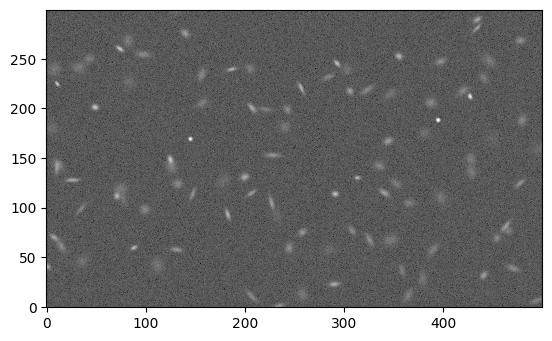

In [ ]:
from photutils.datasets import make_100gaussians_image
data = make_100gaussians_image()

import matplotlib.pyplot as plt
from astropy.visualization import SqrtStretch
from astropy.visualization.mpl_normalize import ImageNormalize
#con el ultimo comando, puedo disminuir la intensidad de los pixeles
norm = ImageNormalize(stretch=SqrtStretch())
plt.imshow(data, norm=norm, origin='lower', cmap='Greys_r',
           interpolation='nearest')
"""
-Con "plt" puedo crear graficos
-Con "imshow" puedo mostrar la imagen que estoy procesando
-Con "cmap" puedo asignar la escala de colores a una grafica
-Con "norm" puedo normalizar los datos la imagen
-Con "origin" puedo asignar el origen de la imagen
-Con "interpolation" puedo asignar la interpolacion de la imagen, es decir,
 asignar valores a datos de los cuales no conocemos su valor, estimandolos
 en base a los datos que si conocemos.
"""


In [ ]:
import numpy as np
#numpy es un paquete para procesar datos en grandes cantidades
#Al parecer, np es para crear un "arreglo" en un rango de valores específicos

from astropy.stats import biweight_location
"""
-"biweigth_location" me sirve para estimar la ubicación central
 (como una medida de tendencia central)
 de un conjunto de datos, similar a la media o la mediana.
 """
print(np.median(data))
print(biweight_location(data))

5.222396450477202
5.187556943476142


In [ ]:
from astropy.stats import sigma_clipped_stats, SigmaClip
#con "sigma_clipped_stats" se calculan estadisticas robustas
from photutils.segmentation import detect_threshold, detect_sources
from photutils.utils import circular_footprint

sigma_clip = SigmaClip(sigma=3.0, maxiters= 10)
threshold = detect_threshold(data, nsigma=2, sigma_clip=sigma_clip)
segment_img= detect_sources(data, threshold, npixels=10)
footprint= circular_footprint(radius= 10)
mask= segment_img.make_source_mask(footprint=footprint)

mean, median, std = sigma_clipped_stats(data, sigma=3.0, mask=mask)
print(np.array((mean, median, std)))

[5.00257401 4.99641799 1.97009566]


Cómo detectar fuentes:

In [ ]:
#para encontrar estrellas hay que saber donde poner tu umbral
#revisar la subseccion de aperture and pixel, "seccion navegation"
"""
Primero buscar las estrellas, despues poner apertura
Estimar el fondo, "angulo", promedio media,
Comparar promedio en la apertura blanca y roja
La apertura nos indica el radio al rededor de la señal de la estrella

Encontrar estrellas en la imagen y  realizar fotometría de apartura en la imagen
"""